# Freie Schwingung
## Messen der Daten
Beim Messen der Daten wurde das Drehpendel pro Messung um 90° ausgelenkt und über einen Zeitraum von 20 Sekunden mit einer speziellen Messsoftware aufgezeichnet. DIe Dämpfung des Drehpendes wurde mithilfe zwei Spulen realisiert, somit war die Dämpfung abhängig von der Stromstärke $I$ die durch die Spuelen floss. Die Messungen wurden bei $0.3$ A angefangen und in $0.1$ A Schritten bis $1.2$ A durchgeführt. Da ab $0.5$ A die Dämpfung so stark war, dass die Schwingung nach 10 Skunden nicht mehr vorhaden war, wurde ab $0.5$ A der Zeitraum der Messungen von 20 Sekunden auf 10 verkürzt.

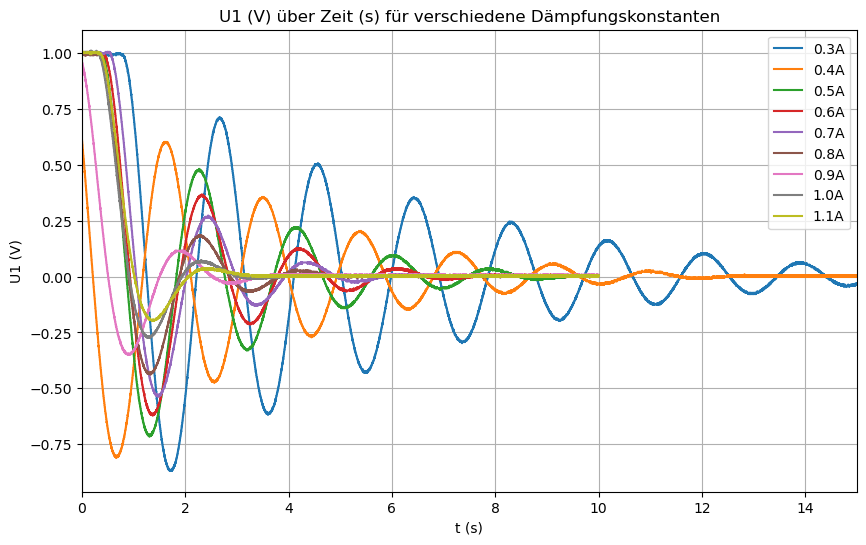

In [14]:
# Plot mit allen Daten von den verschiedenen Dämpfungskonstanten
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Daten einlesen
# Daten aus allen Dateien im Ordner "M10_Aufgabe_1_Daten" einlesen

folder_path = "M10_Aufgabe_1_Daten"
file_names = [f"{i}A_Aufgabe_1_M10.txt" for i in ["0_3", "0_4", "0_5", "0_6", "0_7", "0_8", "0_9", "1_0", "1_1", "1_2"]]

data_frames = []
for file_name in file_names:
    file_path = os.path.join(folder_path, file_name)
    df = pd.read_csv(file_path, sep='\t', names=["t (s)", "U1(V)"], skiprows=1)
    data_frames.append(df)

plt.figure(figsize=(10, 6))
[plt.plot(data_frames[i]["t (s)"], data_frames[i]["U1(V)"], label=f"{(0.3 + 0.1 * (i-1)):.1f}A") for i in range(1, len(data_frames))]
plt.xlim(0, 15)
plt.xlabel("t (s)")
plt.ylabel("U1 (V)")
plt.title("U1 (V) über Zeit (s) für verschiedene Dämpfungskonstanten")
plt.grid()
plt.legend()
plt.show()

## Bestimmung der Frequenz $f_d$ und der Abklingkonstante $\delta$
Um die Frequenz $f_d$ und die Abklingkonstante $\delta$ zu bestimmen, wird jede einzelne Schwingung mit einer Fourieranalyse zerlegt. Der Hauptpeak ist die Frequenz $f_d$. Die Abklingkonstante wird über das logarithmische Dekrement bestimmt.
$$\Lambda  = \delta T_d = ln \left( \frac{\phi (t)}{\phi (t + T_d)} \right)$$
Wobei $T_d = 2\pi/\omega_d$ die Periodendauer ist.

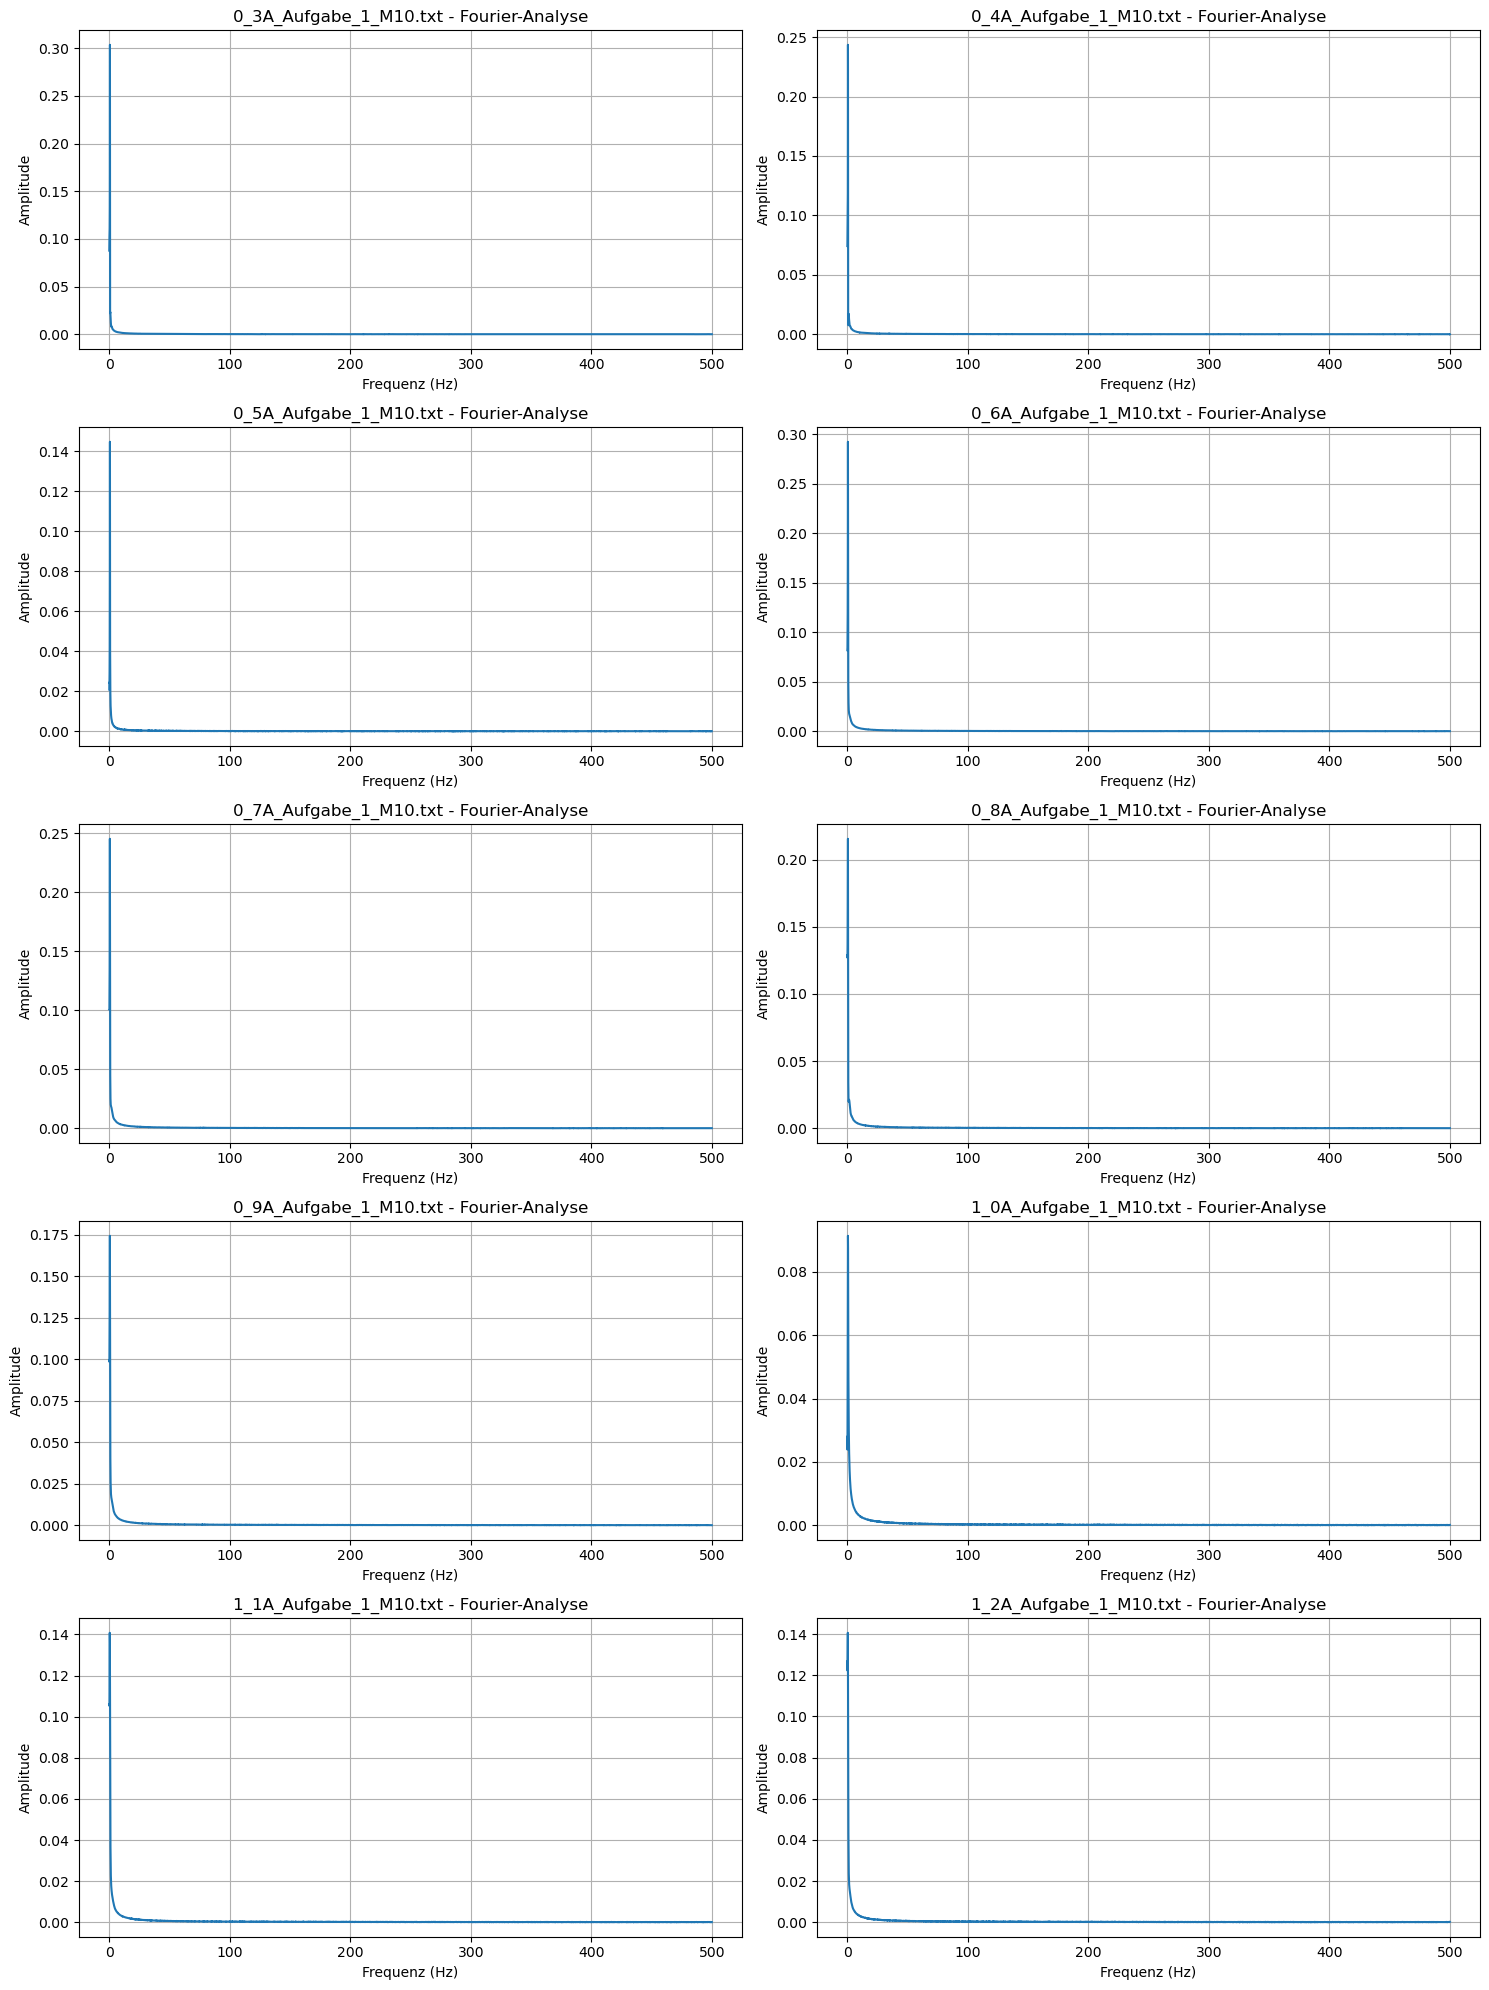

In [15]:
from scipy.fft import fft, fftfreq
# Plot mit allen Daten von den verschiedenen Dämpfungskonstanten
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Daten einlesen
# Daten aus allen Dateien im Ordner "M10_Aufgabe_1_Daten" einlesen

folder_path = "M10_Aufgabe_1_Daten"
file_names = [f"{i}A_Aufgabe_1_M10.txt" for i in ["0_3", "0_4", "0_5", "0_6", "0_7", "0_8", "0_9", "1_0", "1_1", "1_2"]]

data_frames = []
for file_name in file_names:
    file_path = os.path.join(folder_path, file_name)
    df = pd.read_csv(file_path, sep='\t', names=["t (s)", "U1(V)"], skiprows=1)
    data_frames.append(df)

# Subplot erstellen
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten()

# Fourier-Analyse und Plot für jede Datei
for i, df in enumerate(data_frames):
    # Zeit- und Spannungsdaten extrahieren
    t = df["t (s)"].values
    U = df["U1(V)"].values
    
    # Fourier-Transformation
    N = len(t)
    T = t[1] - t[0]  # Abtastintervall
    yf = fft(U)
    xf = fftfreq(N, T)[:N // 2]  # Frequenzen
    
    # Plot der dominanten Frequenz
    axes[i].plot(xf, 2.0 / N * np.abs(yf[:N // 2]))
    axes[i].set_title(f"{file_names[i]} - Fourier-Analyse")
    axes[i].set_xlabel("Frequenz (Hz)")
    axes[i].set_ylabel("Amplitude")
    axes[i].grid()

# Layout anpassen und anzeigen
plt.tight_layout()
plt.show()


## $\omega_d$ als Funktion von $\delta$